# Decision Tree

In [32]:
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

In [33]:
ds = load_dataset("google/code_x_glue_cc_clone_detection_big_clone_bench")

## Equilibrage du dataset de train

In [34]:
df_train = ds['train'].to_pandas()
df_test = ds['test'].to_pandas()

In [35]:
df_val, df_test = train_test_split(
    df_test,
    test_size=0.5, 
    random_state=42, 
    stratify=df_test['label']
)

In [36]:
df_train['label'] = df_train['label'].astype(bool)
df_true = df_train[df_train['label'] == True]
df_false = df_train[df_train['label'] == False]
min_samples = min(len(df_true), len(df_false))

df_true_bal = df_true.sample(n=min_samples, random_state=42)
df_false_bal = df_false.sample(n=min_samples, random_state=42)
df_balanced = pd.concat([df_true_bal, df_false_bal])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

## Vérification de l'équillibrage

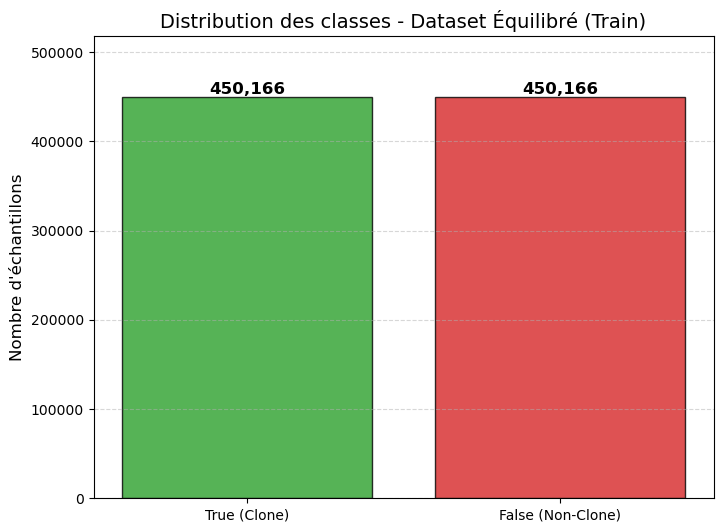

In [37]:
import matplotlib.pyplot as plt

# 1. Vos calculs (extraits de votre demande)
nb_true = len(df_balanced[df_balanced['label'] == True])
nb_false = len(df_balanced[df_balanced['label'] == False])

# 2. Préparation des données pour le graphique
categories = ['True (Clone)', 'False (Non-Clone)']
valeurs = [nb_true, nb_false]
couleurs = ['#2ca02c', '#d62728']  # Vert pour True, Rouge pour False

# 3. Création du graphique
plt.figure(figsize=(8, 6))
barres = plt.bar(categories, valeurs, color=couleurs, edgecolor='black', alpha=0.8)

# 4. Esthétique et Annotations
plt.title('Distribution des classes - Dataset Équilibré (Train)', fontsize=14)
plt.ylabel("Nombre d'échantillons", fontsize=12)
plt.ylim(0, max(valeurs) * 1.15)  # Marge au-dessus pour le texte

# Ajouter les valeurs exactes au-dessus des barres
for barre in barres:
    hauteur = barre.get_height()
    plt.text(barre.get_x() + barre.get_width() / 2.0, hauteur,
             f'{int(hauteur):,}',  # Format avec séparateur de milliers (ex: 450,166)
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


## Préparation du train

In [38]:
# TRAIN (Équilibré)
X_train_text = df_balanced['func1'] + " [SEP] " + df_balanced['func2']
y_train = df_balanced['label']

# VALIDATION (Déséquilibré - Réaliste) -> Pour régler vos hyperparamètres
X_val_text = df_val['func1'] + " [SEP] " + df_val['func2']
y_val = df_val['label']

# TEST (Déséquilibré - Réaliste) -> Pour le verdict final
X_test_text = df_test['func1'] + " [SEP] " + df_test['func2']
y_test = df_test['label']

print(f"Taille Train (Balanced) : {len(df_balanced)}")
print(f"Taille Validation       : {len(df_val)}")
print(f"Taille Test Final       : {len(df_test)}")

Taille Train (Balanced) : 900332
Taille Validation       : 207708
Taille Test Final       : 207708


In [39]:
del df_train, df_test

In [40]:
tfidf = TfidfVectorizer(max_features=100000, stop_words='english')

In [41]:
X_train = tfidf.fit_transform(X_train_text)
X_test = tfidf.transform(X_test_text)

## Entrainement arbre de décision

In [42]:
clf = DecisionTreeClassifier(
    max_depth=50,       # Important pour éviter le surapprentissage et réduire le temps
    random_state=42,
    min_samples_leaf=5,  # Lisse un peu le modèle
)

In [43]:
clf.fit(X_train, y_train)
print("Entraînement terminé.")

Entraînement terminé.


## Evaluation

In [44]:
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)

## Interprétation des résultats

In [45]:
train_acc = clf.score(X_train, y_train)

print(f"Accuracy Train : {train_acc:.4f}")
print(f"Accuracy Test  : {acc:.4f}")

# Calcul de l'écart (Gap)
gap = train_acc - acc
print(f"Ecart : {gap:.4f}")

Accuracy Train : 0.9950
Accuracy Test  : 0.9588
Ecart : 0.0362


On constate une accuracy de 99% sur les données d'entrainment et 95% sur les données de test. Cela montre que notre modéle généralise bien.

In [46]:
print("\nRapport de classification :")
print(classification_report(y_test, y_pred))


Rapport de classification :
              precision    recall  f1-score   support

       False       0.99      0.97      0.98    179298
        True       0.81      0.91      0.86     28410

    accuracy                           0.96    207708
   macro avg       0.90      0.94      0.92    207708
weighted avg       0.96      0.96      0.96    207708



Ce modèle est très performant pour détecter la quasi-totalité des cas positifs (91% de rappel), mais il génère en contrepartie 19% de fausses alertes (précision de 0.81).


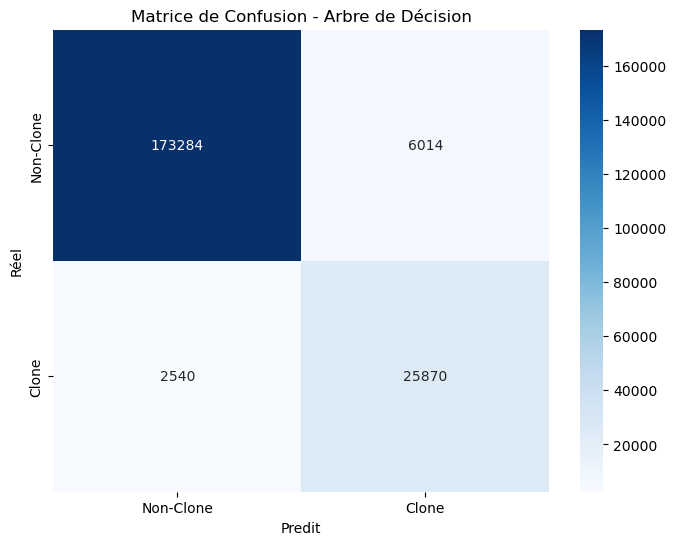

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calcul de la matrice
cm = confusion_matrix(y_test, y_pred)

# Affichage
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-Clone', 'Clone'], 
            yticklabels=['Non-Clone', 'Clone'])
plt.xlabel('Predit')
plt.ylabel('Réel')
plt.title('Matrice de Confusion - Arbre de Décision')
plt.show()

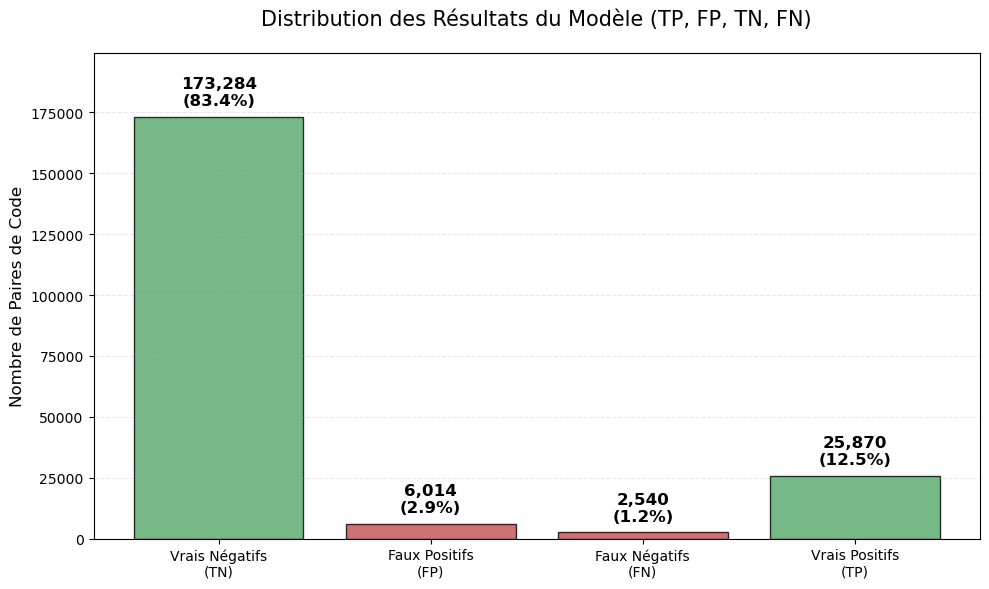

Total des erreurs (FP + FN) : 8554 sur 207708 exemples.
Le modèle a généré 6014 fausses alertes (Faux Positifs).
Le modèle a manqué 2540 clones réels (Faux Négatifs).


In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# 1. Calcul de la matrice de confusion
# cm[0,0]: TN, cm[0,1]: FP, cm[1,0]: FN, cm[1,1]: TP
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

# 2. Préparation des données pour le graphique
categories = ['Vrais Négatifs\n(TN)', 'Faux Positifs\n(FP)', 
              'Faux Négatifs\n(FN)', 'Vrais Positifs\n(TP)']
counts = [tn, fp, fn, tp]
# Couleurs : Vert pour les bonnes prédictions, Rouge pour les erreurs
colors = ['#55a868', '#c44e52', '#c44e52', '#55a868'] 

# 3. Création du diagramme en barres
plt.figure(figsize=(10, 6))
bars = plt.bar(categories, counts, color=colors, edgecolor='black', alpha=0.8)

# 4. Ajout des pourcentages et des valeurs
total = sum(counts)
for bar in bars:
    height = bar.get_height()
    percentage = (height / total) * 100
    plt.text(bar.get_x() + bar.get_width() / 2, height + (max(counts)*0.02), 
             f'{int(height):,}\n({percentage:.1f}%)', 
             ha='center', va='bottom', fontsize=12, fontweight='bold')

# 5. Esthétique
plt.title('Distribution des Résultats du Modèle (TP, FP, TN, FN)', fontsize=15, pad=20)
plt.ylabel('Nombre de Paires de Code', fontsize=12)
plt.ylim(0, max(counts) * 1.15) # Marge au-dessus
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Affichage
plt.tight_layout()
plt.show()

# --- Analyse Textuelle ---
print(f"Total des erreurs (FP + FN) : {fp + fn} sur {total} exemples.")
print(f"Le modèle a généré {fp} fausses alertes (Faux Positifs).")
print(f"Le modèle a manqué {fn} clones réels (Faux Négatifs).")

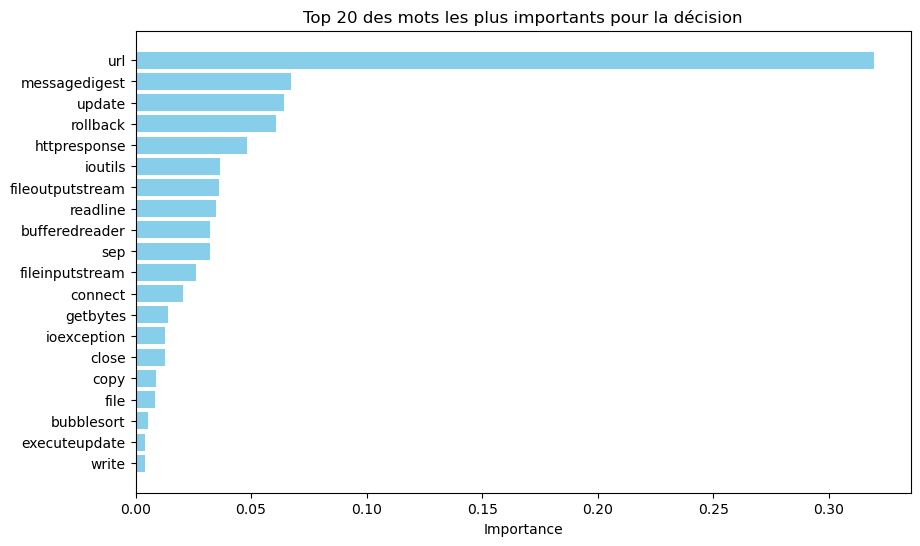

In [49]:
import pandas as pd
import matplotlib.pyplot as plt

# Récupérer les scores d'importance et les mots
importances = clf.feature_importances_
feature_names = tfidf.get_feature_names_out()

# Créer un DataFrame pour trier
feature_importance_df = pd.DataFrame({'word': feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False).head(20)

# Visualisation
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['word'], feature_importance_df['importance'], color='skyblue')
plt.gca().invert_yaxis()
plt.title("Top 20 des mots les plus importants pour la décision")
plt.xlabel("Importance")
plt.show()

Cette analyse montre les principales features (top 20) sur lesquelles s'appuie l’arbre de décision.